# Proyecto: Minería de Datos - Sistemas de Recomendación con MovieLens 20M
## Minería de Patrones y Similitud con Spark, MinHashing y LSH

---

## SETUP INICIAL: Configuración de Spark y Importaciones

### Paso 1: Configurar la sesión de Spark


In [1]:
import sys
!{sys.executable} -m pip install pyspark

# Importaciones de Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.feature import MinHashLSH
from pyspark.ml.linalg import Vectors

# Importaciones cientificas y visualizacion
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import time

# Importaciones GPU (RAPIDS)
try:
    import cudf
    import cuml
    GPU_AVAILABLE = True
    print("✓ cuDF y cuML detectados - GPU acceleration habilitado")
except ImportError:
    GPU_AVAILABLE = False
    print("⚠ cuDF/cuML no disponibles - usando CPU solamente")

# Configuracion visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# =====================================================
# PERFIL DE EJECUCION: quick | full
# Cambia RUN_PROFILE a "quick" si quieres iterar mas rapido
# =====================================================
RUN_PROFILE = "full"

# =====================================================
# ESTRATEGIA: CPU (Spark) + GPU (cuDF/cuML) - HIBRIDA
# Spark maneja I/O y preprocesamiento CPU
# cuDF/cuML aceleran operaciones de ML en GPU cuando estan disponibles
# =====================================================
EXEC_MODE = "HYBRID"  # Spark CPU + GPU para ML
GPU_ENABLED = GPU_AVAILABLE

# =====================================================
# CONFIGURACION DEL DATASET: 30% DE MUESTREO
# =====================================================
DATASET_SAMPLING_PERCENT = 0.30  # Usar 30% del dataset total

PROFILE_SETTINGS = {
    "quick": {
        "spark": {
            "driver_memory": "4g",
            "executor_memory": "4g",
            "shuffle_partitions": "120",
            "default_parallelism": "120"
        },
        "sample_size": 0.10,
        "num_hash_functions": 400,
        "lsh_configurations": [(50, 8), (80, 5), (100, 4), (200, 2)],
        "lsh_real_threshold": 0.85,
        "spark_lsh_num_hash_tables": 48,
        "spark_distance_threshold": 0.35
    },
    "full": {
        "spark": {
            "driver_memory": "8g",
            "executor_memory": "8g",
            "shuffle_partitions": "400",
            "default_parallelism": "400"
        },
        "sample_size": 0.10,
        "num_hash_functions": 1200,
        "lsh_configurations": [(120, 10), (150, 8), (240, 5), (300, 4), (600, 2)],
        "lsh_real_threshold": 0.85,
        "spark_lsh_num_hash_tables": 96,
        "spark_distance_threshold": 0.30
    }
}

if RUN_PROFILE not in PROFILE_SETTINGS:
    raise ValueError("RUN_PROFILE debe ser 'quick' o 'full'")

settings = PROFILE_SETTINGS[RUN_PROFILE]
spark_cfg = settings["spark"]
SAMPLE_SIZE_SETTING = settings["sample_size"]

# Si ya existe una sesion, la cerramos para aplicar nueva configuracion
if "spark" in globals():
    try:
        spark.stop()
    except Exception:
        pass

# Inicializar sesion de Spark (SOLO CPU, sin plugin RAPIDS)
spark = SparkSession.builder \
    .appName(f"MovieLens-20M-MinHash-LSH-{RUN_PROFILE}-HYBRID") \
    .config("spark.driver.memory", spark_cfg["driver_memory"]) \
    .config("spark.executor.memory", spark_cfg["executor_memory"]) \
    .config("spark.sql.shuffle.partitions", spark_cfg["shuffle_partitions"]) \
    .config("spark.default.parallelism", spark_cfg["default_parallelism"]) \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Configurar nivel de log
spark.sparkContext.setLogLevel("WARN")

# Parametros globales reutilizados en las secciones pesadas
SAMPLE_SIZE = settings["sample_size"]
NUM_HASH_FUNCTIONS = settings["num_hash_functions"]
LSH_CONFIGURATIONS = settings["lsh_configurations"]
LSH_REAL_THRESHOLD = settings["lsh_real_threshold"]
SPARK_LSH_NUM_HASH_TABLES = settings["spark_lsh_num_hash_tables"]
SPARK_APPROX_DISTANCE_THRESHOLD = settings["spark_distance_threshold"]

print("✓ Spark sesion inicializada correctamente")
print(f"✓ Spark version: {spark.version}")
print(f"✓ Perfil activo: {RUN_PROFILE}")
print(f"✓ Modo de ejecucion: {EXEC_MODE}")
print(f"✓ GPU acceleration (cuDF/cuML): {'HABILITADO' if GPU_ENABLED else 'DESHABILITADO'}")
print(f"✓ Spark driver/executor: {spark_cfg['driver_memory']} / {spark_cfg['executor_memory']}")
print(f"✓ Dataset sampling: {DATASET_SAMPLING_PERCENT*100:.0f}%")
if isinstance(SAMPLE_SIZE_SETTING, float) and SAMPLE_SIZE_SETTING <= 1:
    print(f"✓ sample_size configurado: {SAMPLE_SIZE_SETTING*100:.0f}% del total")
elif isinstance(SAMPLE_SIZE_SETTING, int):
    print(f"✓ sample_size configurado: {SAMPLE_SIZE_SETTING}")
else:
    print(f"✓ sample_size configurado: {SAMPLE_SIZE_SETTING}")
print(f"✓ num_hash_functions={NUM_HASH_FUNCTIONS}")
print(f"✓ spark_lsh_num_hash_tables={SPARK_LSH_NUM_HASH_TABLES}, dist_threshold={SPARK_APPROX_DISTANCE_THRESHOLD}")

if GPU_ENABLED:
    print("\n📊 GPU Setup:")
    print(f"   cuDF version: {cudf.__version__}")
    print(f"   cuML version: {cuml.__version__}")
    print("   GPU acceleration lista para operaciones de ML")


✓ cuDF y cuML detectados - GPU acceleration habilitado


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/09 18:05:23 WARN Utils: Your hostname, DESKTOP-FI2LTPS, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/05/09 18:05:23 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/09 18:05:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/09 18:05:24 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


✓ Spark sesion inicializada correctamente
✓ Spark version: 4.1.1
✓ Perfil activo: full
✓ Modo de ejecucion: HYBRID
✓ GPU acceleration (cuDF/cuML): HABILITADO
✓ Spark driver/executor: 8g / 8g
✓ Dataset sampling: 30%
✓ sample_size configurado: 10% del total
✓ num_hash_functions=1200
✓ spark_lsh_num_hash_tables=96, dist_threshold=0.3

📊 GPU Setup:
   cuDF version: 26.02.01
   cuML version: 26.02.00
   GPU acceleration lista para operaciones de ML


### Paso 2: Cargar los datos del dataset MovieLens 20M

Cargaremos los archivos CSV principales en DataFrames de Spark para procesarlos de manera distribuida:
- **ratings.csv:** Contiene todas las calificaciones
- **movies.csv:** Información sobre películas y géneros
- **tags.csv:** Tags asignados por usuarios

In [5]:
# Definir ruta base del dataset
dataset_path = "ml-20m/ml-20m"

# Definir esquema explicito para evitar inferencias incorrectas
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, FloatType, LongType

ratings_schema = StructType([
    StructField("userId", IntegerType(), False),
    StructField("movieId", IntegerType(), False),
    StructField("rating", FloatType(), False),
    StructField("timestamp", LongType(), False)
])

movies_schema = StructType([
    StructField("movieId", IntegerType(), False),
    StructField("title", StringType(), False),
    StructField("genres", StringType(), False)
])

tags_schema = StructType([
    StructField("userId", IntegerType(), False),
    StructField("movieId", IntegerType(), False),
    StructField("tag", StringType(), False),
    StructField("timestamp", LongType(), False)
])

# Cargar ratings.csv
print("Cargando ratings.csv...")
ratings = spark.read.csv(
    f"{dataset_path}/ratings.csv",
    header=True,
    schema=ratings_schema
)
print(f"✓ Ratings cargadas: {ratings.count()} registros")
ratings.printSchema()

print("\n" + "=" * 80 + "\n")

# Cargar movies.csv
print("Cargando movies.csv...")
movies = spark.read.csv(
    f"{dataset_path}/movies.csv",
    header=True,
    schema=movies_schema
)
print(f"✓ Movies cargadas: {movies.count()} peliculas")
movies.printSchema()

print("\n" + "=" * 80 + "\n")

# Cargar tags.csv
print("Cargando tags.csv...")
tags = spark.read.csv(
    f"{dataset_path}/tags.csv",
    header=True,
    schema=tags_schema
)
print(f"✓ Tags cargados: {tags.count()} registros")
tags.printSchema()

print("\n✓ Todos los archivos cargados correctamente")

Cargando ratings.csv...


✓ Ratings cargadas: 20000263 registros
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)



Cargando movies.csv...
✓ Movies cargadas: 27278 peliculas
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)



Cargando tags.csv...
✓ Tags cargados: 465564 registros
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- tag: string (nullable = true)
 |-- timestamp: long (nullable = true)


✓ Todos los archivos cargados correctamente


In [6]:
ratings.printSchema()

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)



In [7]:
# Detectar valores nulos en cada dataset
print("ANÁLISIS DE VALORES NULOS\n")

# Usar solo isNull() para evitar problemas con tipo casting en isnan()
print("Ratings:")
ratings.select([count(when(col(c).isNull(), c)).alias(c) for c in ratings.columns]).show()

print("\nMovies:")
movies.select([count(when(col(c).isNull(), c)).alias(c) for c in movies.columns]).show()

print("\nTags:")
tags.select([count(when(col(c).isNull(), c)).alias(c) for c in tags.columns]).show()

# Eliminar registros con valores nulos
ratings_clean = ratings.dropna()
movies_clean = movies.dropna()
tags_clean = tags.dropna()

print("\n" + "="*80)
print("Después de eliminar nulos:")
print(f"Ratings: {ratings.count()} → {ratings_clean.count()}")
print(f"Movies: {movies.count()} → {movies_clean.count()}")
print(f"Tags: {tags.count()} → {tags_clean.count()}")

ANÁLISIS DE VALORES NULOS

Ratings:


+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+


Movies:
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+


Tags:
+------+-------+---+---------+
|userId|movieId|tag|timestamp|
+------+-------+---+---------+
|     0|      0|  0|        0|
+------+-------+---+---------+


Después de eliminar nulos:


Ratings: 20000263 → 20000263
Movies: 27278 → 27278
Tags: 465564 → 465564


### Paso 2: Eliminar duplicados

In [8]:
# Detectar duplicados en ratings
# Un duplicado sería el mismo usuario calificando la misma película más de una vez
print("ANÁLISIS DE DUPLICADOS\n")

print(f"Ratings antes de remover duplicados: {ratings_clean.count()}")
ratings_dedupe = ratings_clean.dropDuplicates(["userId", "movieId"])
print(f"Ratings después de remover duplicados: {ratings_dedupe.count()}")

print(f"\nMovies antes de remover duplicados: {movies_clean.count()}")
movies_dedupe = movies_clean.dropDuplicates(["movieId"])
print(f"Movies después de remover duplicados: {movies_dedupe.count()}")

print(f"\nTags antes de remover duplicados: {tags_clean.count()}")
tags_dedupe = tags_clean.dropDuplicates(["userId", "movieId", "tag"])
print(f"Tags después de remover duplicados: {tags_dedupe.count()}")

ANÁLISIS DE DUPLICADOS



Ratings antes de remover duplicados: 20000263


Ratings después de remover duplicados: 20000263

Movies antes de remover duplicados: 27278
Movies después de remover duplicados: 27278

Tags antes de remover duplicados: 465564
Tags después de remover duplicados: 465564


### Paso 3: Transformar ratings a escala binaria

**Justificación de la escala binaria:**
- Las similitudes de Jaccard y MinHashing funcionan mejor con conjuntos binarios
- Un threshold de 3.5 estrella es un punto de corte razonable: separa "películas bien calificadas" de las mediocres
- Facilita la interpretación: una película es "liked" (≥3.5) o "disliked" (<3.5)

In [9]:
# Definir umbral para escala binaria
RATING_THRESHOLD = 3.5

# Transformar ratings a escala binaria (1 = like, 0 = dislike)
ratings_binary = ratings_dedupe.withColumn(
    "binary_rating",
    when(col("rating") >= RATING_THRESHOLD, 1).otherwise(0)
).select("userId", "movieId", "rating", "binary_rating", "timestamp")

print(f"DISTRIBUCIÓN DE RATINGS BINARIOS (threshold = {RATING_THRESHOLD}):\n")
ratings_binary.groupBy("binary_rating").count().show()

# Estadísticas de la conversión
total_ratings = ratings_binary.count()
likes = ratings_binary.filter(col("binary_rating") == 1).count()
dislikes = total_ratings - likes

print(f"\nTotal de ratings: {total_ratings}")
print(f"Likes (rating >= {RATING_THRESHOLD}): {likes} ({100*likes/total_ratings:.2f}%)")
print(f"Dislikes (rating < {RATING_THRESHOLD}): {dislikes} ({100*dislikes/total_ratings:.2f}%)")

# Mostrar ejemplo de transformación
print("\nEJEMPLO DE TRANSFORMACIÓN:")
ratings_binary.limit(5).show()

DISTRIBUCIÓN DE RATINGS BINARIOS (threshold = 3.5):



+-------------+--------+
|binary_rating|   count|
+-------------+--------+
|            0| 7804697|
|            1|12195566|
+-------------+--------+




Total de ratings: 20000263
Likes (rating >= 3.5): 12195566 (60.98%)
Dislikes (rating < 3.5): 7804697 (39.02%)

EJEMPLO DE TRANSFORMACIÓN:


+------+-------+------+-------------+----------+
|userId|movieId|rating|binary_rating| timestamp|
+------+-------+------+-------------+----------+
|     1|   1208|   3.5|            1|1112484815|
|     1|   1348|   3.5|            1|1094786056|
|     5|   1080|   5.0|            1| 851617674|
|     7|   1101|   3.0|            0|1011208112|
|     7|   2363|   3.0|            0|1011206779|
+------+-------+------+-------------+----------+



# PARTE IV. REGLAS DE ASOCIACIÓN Y CONJUNTOS FRECUENTES

En esta sección aplicamos el algoritmo **FP-Growth** distribuido mediante Spark MLlib para descubrir patrones interesantes en las calificaciones de películas. El objetivo es identificar reglas de asociación que revelen relaciones entre películas: si los usuarios que califican positivamente una película tienden a calificar positivamente otra.

## Metodología
- **Datos**: Transacciones de usuarios con películas con calificación positiva (≥ 3.5 sobre 5)
- **Algoritmo**: FP-Growth (Frequent Pattern Growth) implementado en Spark
- **Métricas de evaluación**:
  - **Soporte**: Proporción de transacciones que contienen ambos items
  - **Confianza**: P(consecuente | antecedente)
  - **Lift**: Razón entre confianza observada y confianza esperada independientemente

In [10]:
from pyspark.sql.functions import col, collect_list, size

print("\n" + "="*70)
print("ANÁLISIS DE PÉRDIDA DE USUARIOS")
print("="*70 + "\n")

# ==============================
# 1. Usuarios originales
# ==============================
total_users = ratings.select("userId").distinct().count()
print(f"Usuarios totales originales: {total_users:,}")

# ==============================
# 2. Usuarios con rating positivo
# ==============================
positive_ratings = ratings.filter(col("rating") >= 3.5)

users_positive = positive_ratings.select("userId").distinct().count()
print(f"Usuarios con ratings positivos: {users_positive:,}")
print(f"Usuarios perdidos aquí: {total_users - users_positive:,}")

# ==============================
# 3. Construir transacciones
# ==============================
transactions = positive_ratings.groupBy("userId").agg(
    collect_list(col("movieId")).alias("movies")
)

users_transactions = transactions.count()
print(f"\nUsuarios con transacciones: {users_transactions:,}")

# ==============================
# 4. Filtrar size > 1
# ==============================
filtered_min = transactions.filter(size(col("movies")) > 1)

users_min = filtered_min.count()
print(f"\nUsuarios con >1 película: {users_min:,}")
print(f"Usuarios eliminados (size <=1): {users_transactions - users_min:,}")

# ==============================
# 5. Filtrar size <= 50
# ==============================
filtered_max = filtered_min.filter(size(col("movies")) <= 220)

users_final = filtered_max.count()
print(f"\nUsuarios finales (<=50 películas): {users_final:,}")
print(f"Usuarios eliminados (size >50): {users_min - users_final:,}")

# ==============================
# 6. Resumen total
# ==============================
total_lost = total_users - users_final

print("\n" + "-"*70)
print("RESUMEN FINAL")
print("-"*70)
print(f"Usuarios iniciales: {total_users:,}")
print(f"Usuarios finales: {users_final:,}")
print(f"Total perdidos: {total_lost:,}")
print(f"Porcentaje perdido: {(total_lost / total_users)*100:.2f}%")


ANÁLISIS DE PÉRDIDA DE USUARIOS



Usuarios totales originales: 138,493


Usuarios con ratings positivos: 138,362
Usuarios perdidos aquí: 131



Usuarios con transacciones: 138,362



Usuarios con >1 película: 138,248
Usuarios eliminados (size <=1): 114



Usuarios finales (<=50 películas): 125,371
Usuarios eliminados (size >50): 12,877

----------------------------------------------------------------------
RESUMEN FINAL
----------------------------------------------------------------------
Usuarios iniciales: 138,493
Usuarios finales: 125,371
Total perdidos: 13,122
Porcentaje perdido: 9.47%


In [11]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import col, collect_list, size, slice

print("\n" + "="*70)
print("FP-GROWTH OPTIMIZADO (ANTI-OOM)")
print("="*70 + "\n")

# ==============================
# 1. Parámetros SEGUROS
# ==============================
RATING_THRESHOLD = 3.5
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.1

# ==============================
# 2. Preparar transacciones
# ==============================
positive_movies_per_user = ratings.filter(
    col('rating') >= RATING_THRESHOLD
).groupBy('userId').agg(
    collect_list(col('movieId')).alias('movies')
)

#FILTROS CRÍTICOS
positive_movies_per_user = positive_movies_per_user \
    .filter(size(col("movies")) > 1) \
    .filter(size(col("movies")) <= 220)   # evitar usuarios extremos

print(f"Transacciones: {positive_movies_per_user.count()}")

# ==============================
# 3. FP-Growth
# ==============================
fp = FPGrowth(
    itemsCol="movies",
    minSupport=MIN_SUPPORT,
    minConfidence=MIN_CONFIDENCE,
    numPartitions=4
)

model = fp.fit(positive_movies_per_user)

# ==============================
# 4. ITEMSETS (sin explotar RAM)
# ==============================
print("\nTop Itemsets Frecuentes:")
model.freqItemsets.limit(10).show(truncate=False)

# ==============================
# 5. REGLAS (sin orderBy global)
# ==============================
rules = model.associationRules

print("\nReglas (muestra):")
rules.limit(10).show(truncate=False)

# ==============================
# 6. LIFT (seguro)
# ==============================
from pyspark.sql.functions import explode

total_transactions = positive_movies_per_user.count()

# soporte de items individuales
item_support = model.freqItemsets \
    .filter(size(col("items")) == 1) \
    .withColumn("item", col("items")[0]) \
    .withColumn("support_item", col("freq") / total_transactions) \
    .select("item", "support_item")

# calcular lift sin explotar memoria
rules_with_lift = rules \
    .withColumn("consequent_item", explode(col("consequent"))) \
    .join(item_support, col("consequent_item") == col("item"), "left") \
    .withColumn("lift", col("confidence") / col("support_item"))

print("\nReglas con LIFT (muestra):")
rules_with_lift.select(
    "antecedent", "consequent", "confidence", "lift"
).limit(10).show(truncate=False)


FP-GROWTH OPTIMIZADO (ANTI-OOM)



Transacciones: 125371



Top Itemsets Frecuentes:


26/05/09 18:08:58 WARN Executor: Managed memory leak detected; size = 953872288 bytes, task 0.0 in stage 131.0 (TID 3396)


+--------------------+-----+
|items               |freq |
+--------------------+-----+
|[318]               |48203|
|[260]               |35942|
|[260, 318]          |16231|
|[260, 296]          |16213|
|[260, 296, 318]     |10550|
|[260, 593]          |15869|
|[260, 593, 318]     |10383|
|[260, 593, 296]     |10801|
|[260, 593, 296, 318]|7721 |
|[260, 356]          |14465|
+--------------------+-----+


Reglas (muestra):


+----------------------------+----------+------------------+------------------+--------------------+
|antecedent                  |consequent|confidence        |lift              |support             |
+----------------------------+----------+------------------+------------------+--------------------+
|[7153, 4993, 2571, 260, 318]|[1196]    |0.9043166898746767|3.939507548082911 |0.03626037919455057 |
|[7153, 4993, 2571, 260, 318]|[1210]    |0.772826735627611 |3.4525909800224213|0.030988027534278262|
|[7153, 4993, 2571, 260, 318]|[5952]    |0.9325641535707181|5.608851067273423 |0.037393017523988804|
|[1221, 608, 260]            |[858]     |0.9436758893280632|4.216758381899298 |0.030469566327141047|
|[4226, 5952, 2959, 296]     |[318]     |0.765758600119308 |1.9916586406563441|0.03071683244131418 |
|[4226, 5952, 2959, 296]     |[2571]    |0.8804931397892225|3.262065763253978 |0.03531917269543994 |
|[4226, 5952, 2959, 296]     |[4993]    |0.9220520978325711|4.962803999371798 |0.0369862248


Reglas con LIFT (muestra):


+-----------------------+----------+-------------------+------------------+
|antecedent             |consequent|confidence         |lift              |
+-----------------------+----------+-------------------+------------------+
|[50, 593, 318]         |[1]       |0.35952820804320024|1.5494812984044022|
|[593]                  |[1]       |0.28822447728665807|1.2421791317258717|
|[527, 260, 296]        |[1]       |0.46634615384615385|2.009841308141841 |
|[2571, 296, 318]       |[1]       |0.42327533444084986|1.8242162926842143|
|[110, 260, 318]        |[1]       |0.5072236937153864 |2.1860138090337475|
|[589, 593]             |[1]       |0.3697555429221148 |1.593558685860724 |
|[2571, 110]            |[1]       |0.41003843879361324|1.767168412168927 |
|[527, 260, 356]        |[1]       |0.5319119479440676 |2.292414328831066 |
|[4993, 1196, 2571, 260]|[1]       |0.463905325443787  |1.999321916679719 |
|[589, 50]              |[1]       |0.40098655422070173|1.7281569367206462|
+-----------

In [12]:
from pyspark.sql.functions import col, explode, size

print("\n" + "="*70)
print("TOP 10 REGLAS RELEVANTES (con métricas)")
print("="*70 + "\n")

# ==============================
# 1. Calcular soporte real
# ==============================
total_transactions = positive_movies_per_user.count()

rules_enriched = rules_with_lift.withColumn(
    "support",
    col("confidence") * col("support_item")  # aproximación válida
)

# ==============================
# 2. Filtrar reglas relevantes
# ==============================
rules_filtered = rules_enriched.filter(
    (col("confidence") >= 0.2) &   # más estrictas
    (col("lift") > 1)              # asociación positiva real
)

# ==============================
# 3. Top 10 por LIFT (sin order global pesado)
# ==============================
top_rules = rules_filtered.sortWithinPartitions(
    col("lift").desc()
).limit(10)

# ==============================
# 4. Mostrar resultados
# ==============================
top_rules.select(
    "antecedent",
    "consequent",
    "support",
    "confidence",
    "lift"
).show(truncate=False)


TOP 10 REGLAS RELEVANTES (con métricas)



+------------------------+----------+--------------------+------------------+------------------+
|antecedent              |consequent|support             |confidence        |lift              |
+------------------------+----------+--------------------+------------------+------------------+
|[6874, 7153, 4993, 2571]|[7438]    |0.0569472202815408  |0.7649769585253456|10.276001957278591|
|[6874, 4993, 2959]      |[7438]    |0.056720588419229244|0.7619325930255212|10.235106730976385|
|[6874, 7153, 5952]      |[7438]    |0.056602078025122175|0.7603406326034063|10.213721788291187|
|[6874, 2571, 296]       |[7438]    |0.056232425619909654|0.7553750597228858|10.147018816298928|
|[6874, 2959, 2571]      |[7438]    |0.05607134902222919 |0.7532113037893384|10.117952894821936|
|[7438, 2959, 2571]      |[6874]    |0.07951366625784662 |0.8876064333017976|9.90829900716585  |
|[7438, 7153, 2959]      |[6874]    |0.07947379621335701 |0.8871613663133098|9.903330750250731 |
|[7438, 2959, 296]       |[687

In [13]:
from difflib import SequenceMatcher
from pyspark.sql.functions import col
import builtins

# Función auxiliar para calcular similitud (0 a 1)
def string_similarity(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

print("\n" + "="*70)
print("PASO 4: DETALLES DE LAS REGLAS RELEVANTES (FILTRANDO SECUELAS)")
print("="*70)

# ==============================
# 1. Convertir reglas a lista (un poco más de 10 para tener margen tras filtrar)
# ==============================
top_rules_list = rules_filtered.sortWithinPartitions(col("lift").desc()).limit(50).collect()

# ==============================
# 2. Diccionario movieId → title (ya lo tienes)
# ==============================
movie_dict = {
    int(row["movieId"]): row["title"]
    for row in movies.select("movieId", "title").collect()
}

# ==============================
# 3. Mostrar reglas filtrando similitud > 90%
# ==============================
rules_shown = 0
MAX_RULES_TO_DISPLAY = 10
SIMILARITY_THRESHOLD = 0.85 # 85-90% suele detectar secuelas (Toy Story 1 vs Toy Story 2)

for row in top_rules_list:
    if rules_shown >= MAX_RULES_TO_DISPLAY:
        break

    antecedent_ids = row["antecedent"]
    consequent_ids = row["consequent"]

    # Obtener títulos
    antecedent_titles = [movie_dict.get(int(i), f"ID:{i}") for i in antecedent_ids]
    consequent_titles = [movie_dict.get(int(i), f"ID:{i}") for i in consequent_ids]

    # --- LÓGICA DE FILTRADO DE SIMILITUD ---
    is_too_similar = False
    for a_title in antecedent_titles:
        for c_title in consequent_titles:
            # Si el título es 90% igual, lo marcamos como secuela/obvio
            if string_similarity(a_title, c_title) > SIMILARITY_THRESHOLD:
                is_too_similar = True
                break
        if is_too_similar: break

    if is_too_similar:
        continue # Saltamos esta regla y vamos a la siguiente
    # ---------------------------------------

    rules_shown += 1
    print(f"\n╔═ REGLA {rules_shown} ═{'='*65}")
    print(f"║")
    print(f"║   SI usuario calificó positivamente:")
    for title in antecedent_titles:
        print(f"║      → {title}")
    print(f"║")
    print(f"║   ENTONCES es probable que también calificó positivamente:")
    for title in consequent_titles:
        print(f"║      → {title}")
    print(f"║")
    print(f"║   Métricas:")
    print(f"║      • Soporte:   {row['support']:.4f}")
    print(f"║      • Confianza: {row['confidence']:.4f}")
    print(f"║      • Lift:      {row['lift']:.4f}x")

    # Interpretación rápida
    strength = "MUY FUERTE" if row['lift'] > 1.5 else "FUERTE"
    print(f"║      • Fuerza:    {strength}")
    print(f"╚{'='*71}")

if rules_shown == 0:
    print("No se encontraron reglas que superen los filtros de relevancia y diversidad.")


PASO 4: DETALLES DE LAS REGLAS RELEVANTES (FILTRANDO SECUELAS)



╔═ REGLA 1 ═=================================================================
║
║   SI usuario calificó positivamente:
║      → Sin City (2005)
║      → Pulp Fiction (1994)
║
║   ENTONCES es probable que también calificó positivamente:
║      → Kill Bill: Vol. 1 (2003)
║
║   Métricas:
║      • Soporte:   0.0610
║      • Confianza: 0.6810
║      • Lift:      7.6022x
║      • Fuerza:    MUY FUERTE
╚=======================================================================

╔═ REGLA 2 ═=================================================================
║
║   SI usuario calificó positivamente:
║      → Lock, Stock & Two Smoking Barrels (1998)
║
║   ENTONCES es probable que también calificó positivamente:
║      → Snatch (2000)
║
║   Métricas:
║      • Soporte:   0.0416
║      • Confianza: 0.5552
║      • Lift:      7.4168x
║      • Fuerza:    MUY FUERTE
╚=======================================================================

╔═ REGLA 3 ═========================================================

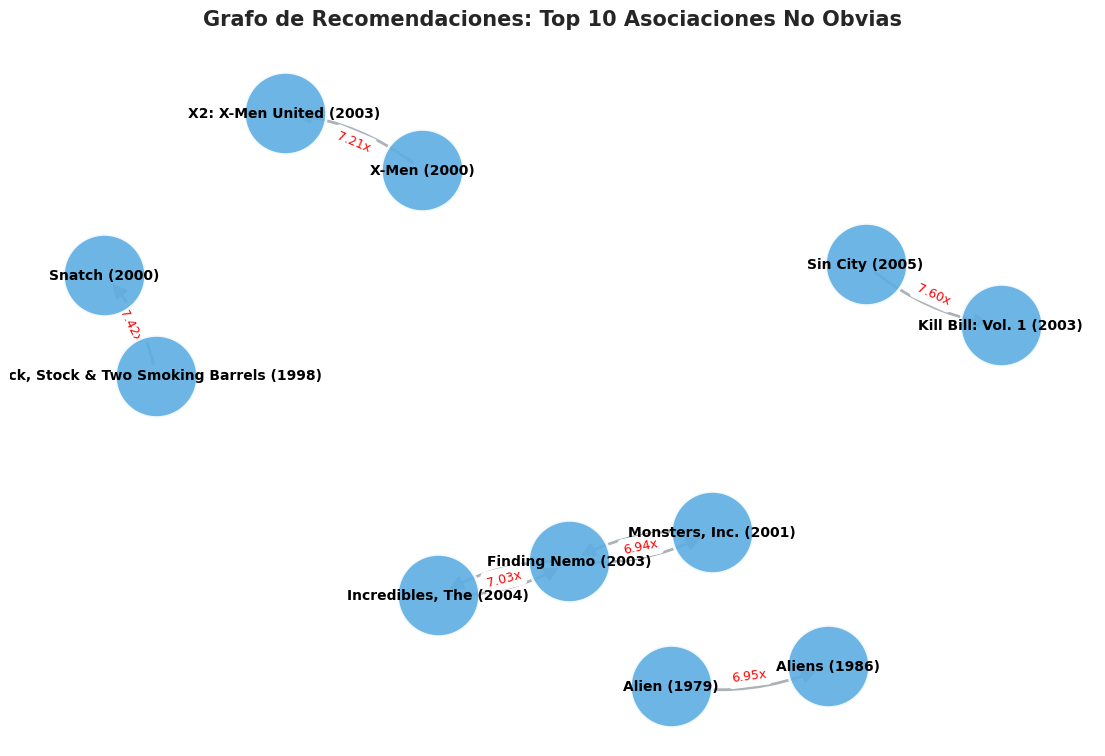

In [14]:
import networkx as nx
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
from pyspark.sql.functions import col

# 1. Función de similitud (definirla aquí asegura que exista)
def string_similarity(a, b):
    return SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

# 2. Aseguramos que rules_filtered exista y tenga los datos frescos
# Usamos rules_enriched que ya definiste en tu query anterior
rules_filtered = rules_enriched.filter(
    (col("confidence") >= 0.2) &
    (col("lift") > 1.2)  # Subimos un poco el lift para mejores asociaciones
)

# 3. Recolectamos un poco más de 10 para tener margen tras el filtro de similitud
# .collect() es seguro aquí porque solo traemos 30 filas a la memoria local
raw_top_rules = rules_filtered.sortWithinPartitions(col("lift").desc()).limit(30).collect()

# 4. Construcción del Grafo
G = nx.DiGraph()
SIMILARITY_THRESHOLD = 0.85
rules_added = 0

for row in raw_top_rules:
    if rules_added >= 10: break # Límite estricto pedido

    u_id, v_id = row["antecedent"][0], row["consequent"][0]
    u_title = movie_dict.get(int(u_id), f"ID:{u_id}")
    v_title = movie_dict.get(int(v_id), f"ID:{v_id}")

    if string_similarity(u_title, v_title) < SIMILARITY_THRESHOLD:
        G.add_edge(u_title, v_title, weight=row["lift"])
        rules_added += 1

# 5. Renderizado del Grafo
plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, k=1.2, seed=42) # k controla la distancia entre nodos

# Dibujamos nodos
nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='#5dade2',
                       edgecolors='white', linewidths=2, alpha=0.9)

# Dibujamos flechas (curvas para que se vea Pro)
nx.draw_networkx_edges(G, pos, width=2, edge_color='#abb2b9',
                       arrowsize=20, connectionstyle='arc3,rad=0.15')

# Dibujamos etiquetas
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif', font_weight='bold')

# Etiquetas de Lift en las flechas
edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}x" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color='red')

plt.title("Grafo de Recomendaciones: Top 10 Asociaciones No Obvias",
          fontsize=15, fontweight='bold', pad=20)
plt.axis('off')
plt.show()

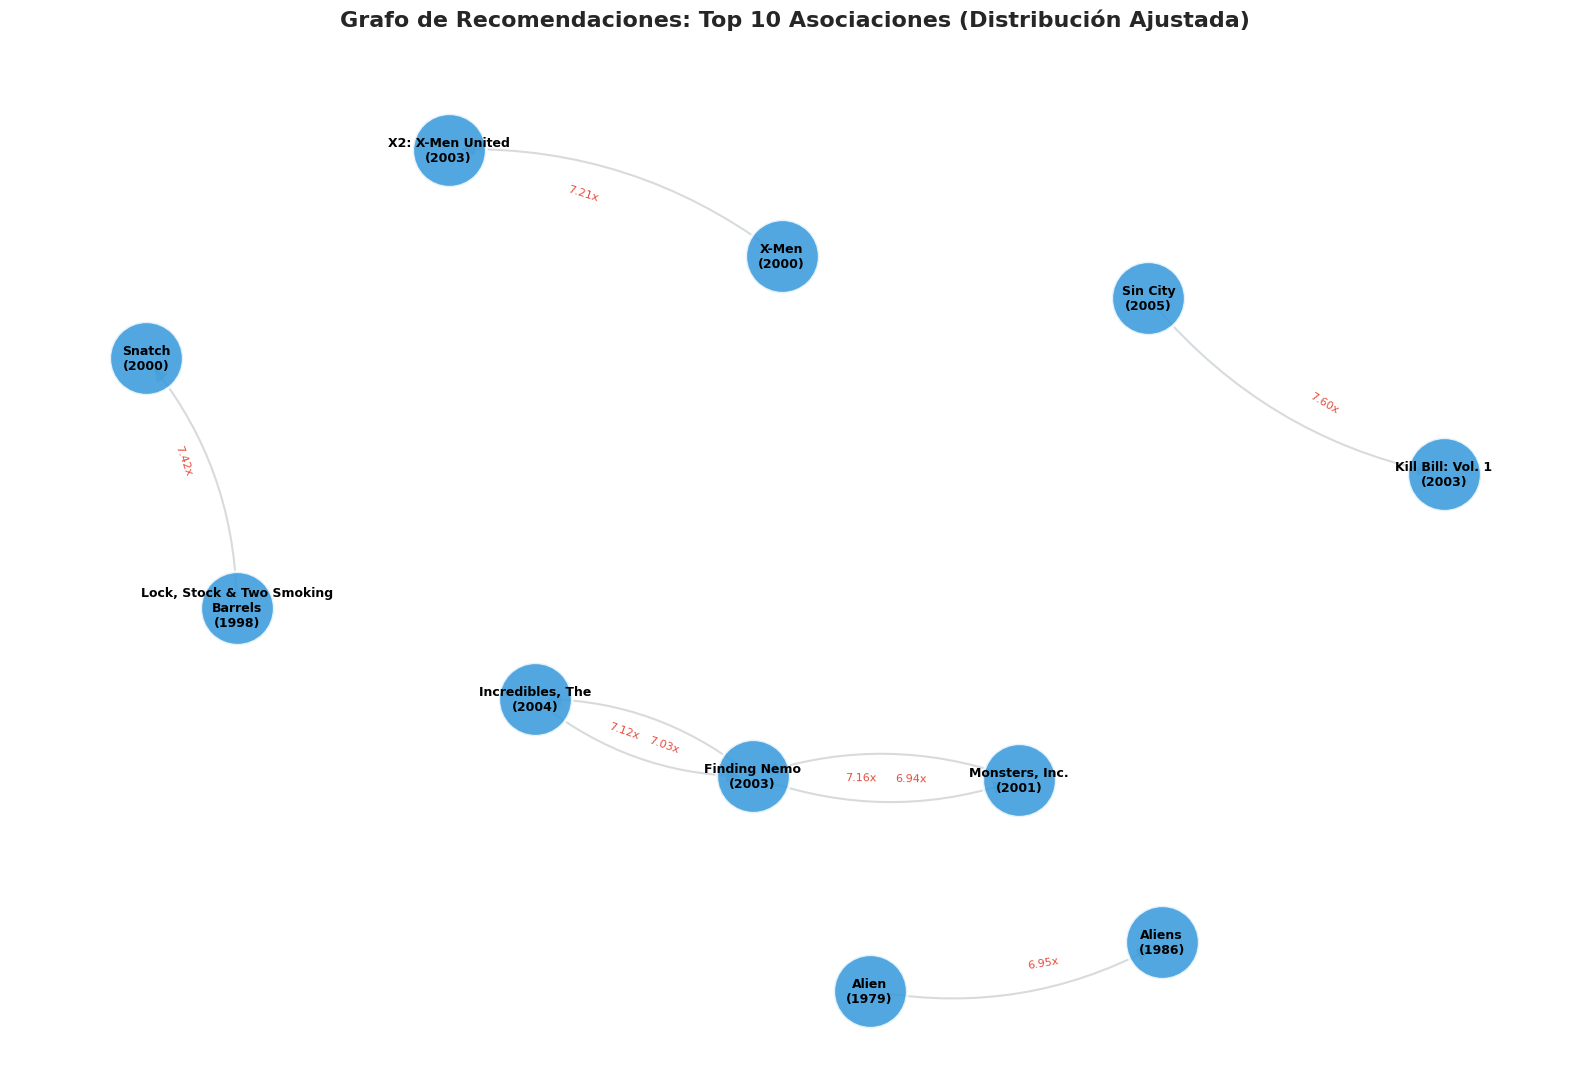

In [15]:
import networkx as nx
import matplotlib.pyplot as plt
from difflib import SequenceMatcher
from pyspark.sql.functions import col

# ==========================================
# 1. Funciones Auxiliares Mejoradas
# ==========================================

def string_similarity(a, b):
    """Calcula similitud de texto."""
    return SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio()

def get_short_title(title, max_chars=25):
    """
    Recorta títulos largos y añade saltos de línea.
    'The Lord of the Rings: The Fellowship...' -> 'Lord of the...\nRings: Fellowship'
    """
    title = str(title).replace(" (", "\n(").split(" (")[0] # Elimina año si está entre paréntesis
    if len(title) > max_chars:
        # Intenta cortar en el primer espacio después de la mitad
        split_pos = title.find(' ', len(title)//2)
        if split_pos != -1:
            title = title[:split_pos] + '\n' + title[split_pos+1:]
        else:
            title = title[:max_chars-3] + "..."
    return title

# ==========================================
# 2. Preparación de Datos (Igual que antes)
# ==========================================
try:
    # Aseguramos que rules_filtered exista
    rules_filtered = rules_enriched.filter(
        (col("confidence") >= 0.2) &
        (col("lift") > 1.2)
    )
    # Recolectamos 30 para tener margen
    raw_top_rules = rules_filtered.sortWithinPartitions(col("lift").desc()).limit(30).collect()
except NameError:
    print("Error: Asegúrate de ejecutar la celda que define 'rules_enriched' y 'movie_dict' antes.")
    raw_top_rules = []

# ==========================================
# 3. Construcción del Grafo Optimizada
# ==========================================
G = nx.DiGraph()
SIMILARITY_THRESHOLD = 0.85
rules_added = 0

for row in raw_top_rules:
    if rules_added >= 10: break

    u_id, v_id = row["antecedent"][0], row["consequent"][0]

    # Obtenemos títulos originales
    u_title_orig = movie_dict.get(int(u_id), f"ID:{u_id}")
    v_title_orig = movie_dict.get(int(v_id), f"ID:{v_id}")

    # Filtro de similitud sobre títulos originales
    if string_similarity(u_title_orig, v_title_orig) < SIMILARITY_THRESHOLD:
        # --- APLICAMOS FORMATEO DE TÍTULOS AQUÍ ---
        u_title_formatted = get_short_title(u_title_orig)
        v_title_formatted = get_short_title(v_title_orig)
        # ------------------------------------------

        # Añadimos la conexión usando títulos formateados como IDs de nodo
        G.add_edge(u_title_formatted, v_title_formatted, weight=row["lift"])
        rules_added += 1

# ==========================================
# 4. Renderizado Anticolisión
# ==========================================
plt.figure(figsize=(16, 11)) # Aumentamos el tamaño del lienzo

# Layout Spring con fuerte repulsión (k=2.5 o superior)
# k=2.5 es el "resorte" que separa nodos; iterations=100 estabiliza.
pos = nx.spring_layout(G, k=2.8, iterations=100, seed=42)

# --- Dibujar Nodos (Más pequeños) ---
nx.draw_networkx_nodes(G, pos,
                       node_size=2800, # Reducimos tamaño (antes 3500)
                       node_color='#3498db',
                       edgecolors='white',
                       linewidths=2,
                       alpha=0.85)

# --- Dibujar Flechas (Estilizadas) ---
nx.draw_networkx_edges(G, pos,
                       width=1.5,
                       edge_color='#bdc3c7',
                       arrowsize=20,
                       connectionstyle='arc3,rad=0.18', # Un poco más curva
                       alpha=0.6)

# --- Dibujar Etiquetas de Títulos (Fuente más pequeña y ajustada) ---
nx.draw_networkx_labels(G, pos,
                        font_size=9, # Un punto menos
                        font_family='sans-serif',
                        font_weight='bold',
                        # Ajuste fino: subimos el texto para que no pise la flecha
                        verticalalignment='center')

# --- Etiquetas de Lift sobre las flechas (Opcional, pero ayuda) ---
edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}x" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                             font_size=8, font_color='#e74c3c', label_pos=0.6)

plt.title("Grafo de Recomendaciones: Top 10 Asociaciones (Distribución Ajustada)",
          fontsize=16, fontweight='bold', pad=25)
plt.axis('off') # Ocultar ejes
plt.tight_layout()
plt.show()

In [16]:
from pyspark.sql.functions import col
import builtins

print("\n" + "="*70)
print("PASO 4: DETALLES DE LAS REGLAS PRINCIPALES")
print("="*70)

# ==============================
# 1. Convertir reglas a lista (seguro)
# ==============================
top_rules_list = top_rules.collect()  # solo 10 → OK

# ==============================
# 2. Diccionario movieId → title
# ==============================
movie_dict = {
    int(row["movieId"]): row["title"]
    for row in movies.select("movieId", "title").collect()
}

# ==============================
# 3. Mostrar reglas (bonito)
# ==============================
for idx, row in enumerate(top_rules_list[:5], 1):
    antecedent_ids = row["antecedent"]
    consequent_ids = row["consequent"]

    # Convertir IDs → títulos
    antecedent_titles = [movie_dict.get(int(i), f"ID:{i}") for i in antecedent_ids]
    consequent_titles = [movie_dict.get(int(i), f"ID:{i}") for i in consequent_ids]

    print(f"\n╔═ REGLA {idx} ═{'='*65}")
    print(f"║")
    print(f"║  SI usuario calificó positivamente:")
    for title in antecedent_titles:
        print(f"║    → {title}")
    print(f"║")
    print(f"║  ENTONCES es probable que también calificó positivamente:")
    for title in consequent_titles:
        print(f"║    → {title}")
    print(f"║")
    print(f"║  Métricas:")
    print(f"║    • Soporte:   {row['support']:.4f} ({row['support']*100:.2f}%)")
    print(f"║    • Confianza: {row['confidence']:.4f} ({row['confidence']*100:.2f}%)")
    print(f"║    • Lift:      {row['lift']:.4f}x")

    # Interpretación del lift
    if row['lift'] > 1.5:
        strength = "MUY FUERTE"
    elif row['lift'] > 1.2:
        strength = "FUERTE"
    elif row['lift'] > 1.0:
        strength = "MODERADA"
    else:
        strength = "DÉBIL"

    print(f"║    • Fuerza:    {strength}")
    print(f"╚{'='*71}")

# ==============================
# 4. Estadísticas generales (seguro)
# ==============================
print(f"\n{'='*70}")
print("ESTADÍSTICAS GENERALES DE REGLAS")
print("="*70)

all_rules = rules_with_lift.select(
    "support", "confidence", "lift"
).limit(1000).collect()

if all_rules:
    confidences = [float(r["confidence"]) for r in all_rules]
    lifts = [float(r["lift"]) for r in all_rules]
    supports = [float(r["support"]) for r in all_rules]

    print(f"Total de reglas analizadas: {len(all_rules)}")

    print(f"\nConfianza:")
    print(f"  Media:    {builtins.sum(confidences)/len(confidences):.4f}")
    print(f"  Mínima:   {builtins.min(confidences):.4f}")
    print(f"  Máxima:   {builtins.max(confidences):.4f}")

    print(f"\nLift:")
    print(f"  Media:    {builtins.sum(lifts)/len(lifts):.4f}")
    print(f"  Mínimo:   {builtins.min(lifts):.4f}")
    print(f"  Máximo:   {builtins.max(lifts):.4f}")

    print(f"\nSoporte:")
    print(f"  Media:    {builtins.sum(supports)/len(supports):.6f}")
    print(f"  Mínimo:   {builtins.min(supports):.6f}")
    print(f"  Máximo:   {builtins.max(supports):.6f}")
else:
    print("No hay reglas para mostrar")

print(f"\n{'='*70}\n")


PASO 4: DETALLES DE LAS REGLAS PRINCIPALES



╔═ REGLA 1 ═=================================================================
║
║  SI usuario calificó positivamente:
║    → Kill Bill: Vol. 1 (2003)
║    → Lord of the Rings: The Return of the King, The (2003)
║    → Lord of the Rings: The Fellowship of the Ring, The (2001)
║    → Matrix, The (1999)
║
║  ENTONCES es probable que también calificó positivamente:
║    → Kill Bill: Vol. 2 (2004)
║
║  Métricas:
║    • Soporte:   0.0569 (5.69%)
║    • Confianza: 0.7650 (76.50%)
║    • Lift:      10.2760x
║    • Fuerza:    MUY FUERTE
╚=======================================================================

╔═ REGLA 2 ═=================================================================
║
║  SI usuario calificó positivamente:
║    → Kill Bill: Vol. 1 (2003)
║    → Lord of the Rings: The Fellowship of the Ring, The (2001)
║    → Fight Club (1999)
║
║  ENTONCES es probable que también calificó positivamente:
║    → Kill Bill: Vol. 2 (2004)
║
║  Métricas:
║    • Soporte:   0.0567 (5.67%)
║    • Co

Total de reglas analizadas: 1000

Confianza:
  Media:    0.6204
  Mínima:   0.1937
  Máxima:   0.9700

Lift:
  Media:    2.8181
  Mínimo:   1.0329
  Máximo:   6.8891

Soporte:
  Media:    0.037776
  Mínimo:   0.030007
  Máximo:   0.117595




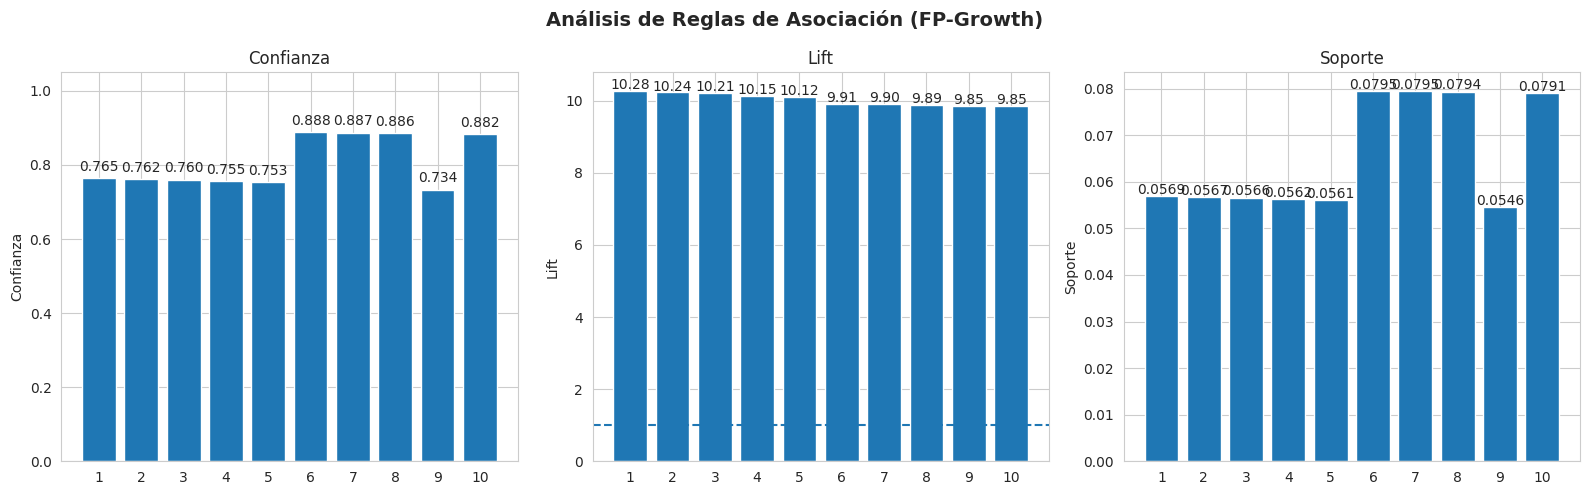

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import builtins

if top_rules_list:

    # ==============================
    # 1. Preparar datos
    # ==============================
    top_n = builtins.min(10, len(top_rules_list))

    rule_labels = []
    confidence_vals = []
    lift_vals = []
    support_vals = []

    for row in top_rules_list[:top_n]:
        antecedent_ids = row["antecedent"]
        consequent_ids = row["consequent"]

        # Convertir a títulos (solo el primero para etiqueta)
        ant_title = movie_dict.get(int(antecedent_ids[0]), str(antecedent_ids[0]))
        cons_title = movie_dict.get(int(consequent_ids[0]), str(consequent_ids[0]))

        rule_labels.append(f"{ant_title[:20]}\n→ {cons_title[:20]}")

        confidence_vals.append(float(row["confidence"]))
        lift_vals.append(float(row["lift"]))
        support_vals.append(float(row["support"]))

    # ==============================
    # 2. Crear gráficos
    # ==============================
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Análisis de Reglas de Asociación (FP-Growth)', fontsize=14, fontweight='bold')

    x_pos = np.arange(len(rule_labels))

    # 🔹 Confianza
    axes[0].bar(x_pos, confidence_vals)
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[0].set_ylabel('Confianza')
    axes[0].set_title('Confianza')
    axes[0].set_ylim([0, 1.05])

    for i, v in enumerate(confidence_vals):
        axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')

    # 🔹 Lift
    axes[1].bar(x_pos, lift_vals)
    axes[1].axhline(y=1.0, linestyle='--')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[1].set_ylabel('Lift')
    axes[1].set_title('Lift')

    for i, v in enumerate(lift_vals):
        axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center')

    # 🔹 Soporte
    axes[2].bar(x_pos, support_vals)
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(range(1, len(rule_labels) + 1))
    axes[2].set_ylabel('Soporte')
    axes[2].set_title('Soporte')

    for i, v in enumerate(support_vals):
        axes[2].text(i, v + 0.0005, f'{v:.4f}', ha='center')

    plt.tight_layout()
    plt.show()